In [1]:
from pathlib import Path

data_path=Path("Dataset/")
image_path=data_path/"train"

print(image_path)

Dataset\train


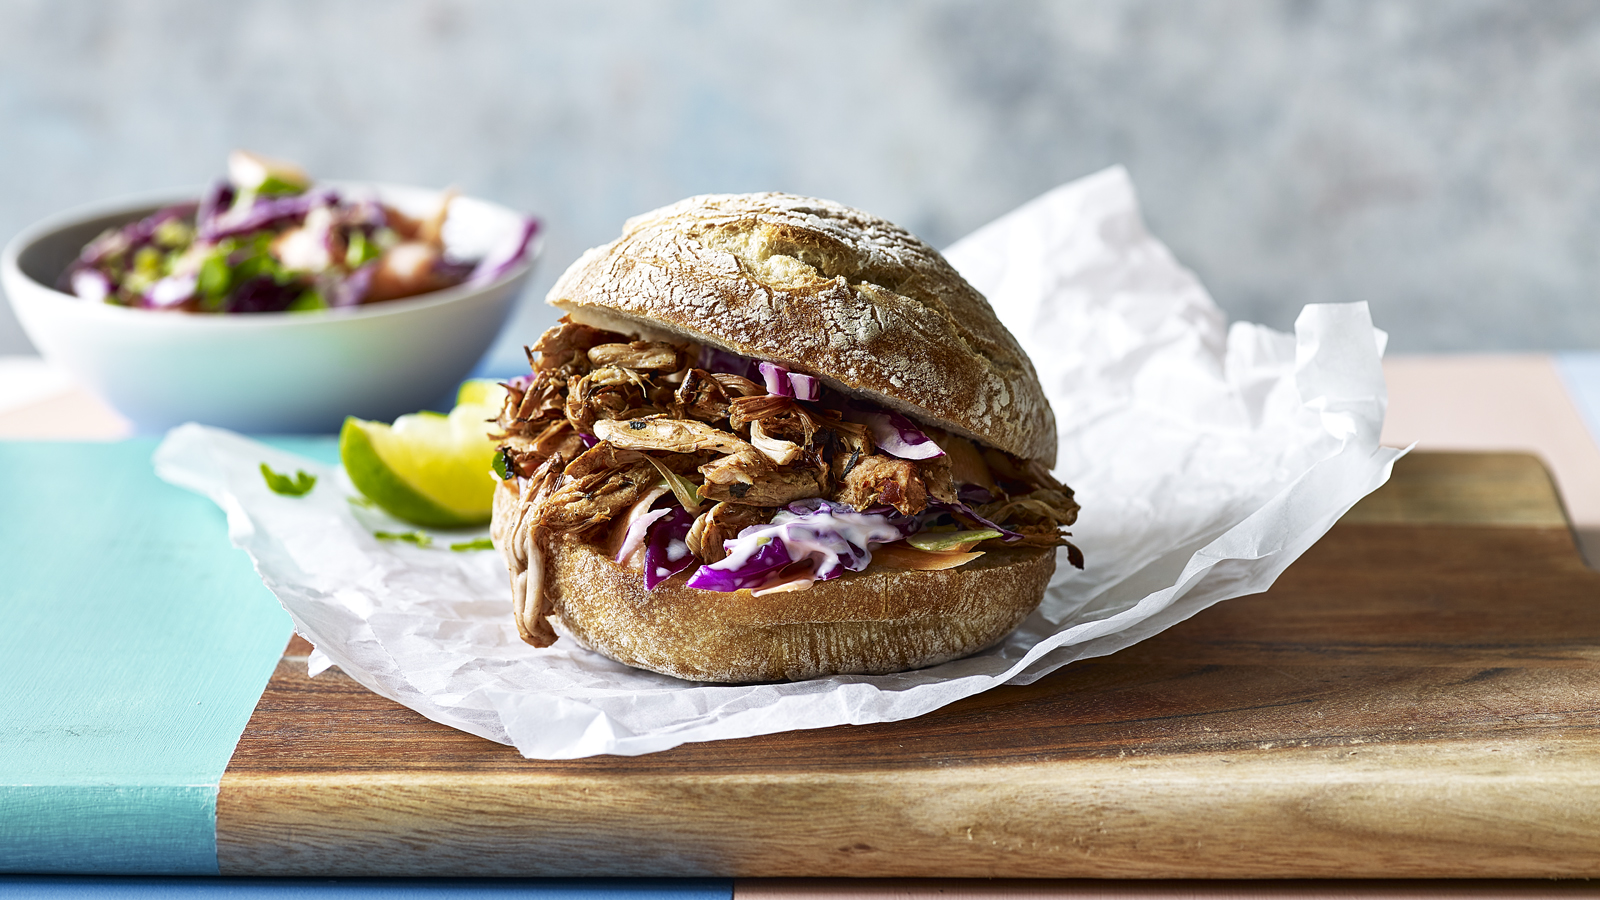

In [2]:
from PIL import Image
import random

image_path_list=list(image_path.glob('./*/*.jpg'))
image_path_list

random_image_path=random.choice(image_path_list)
image=Image.open(random_image_path)
image

(-0.5, 1599.5, 899.5, -0.5)

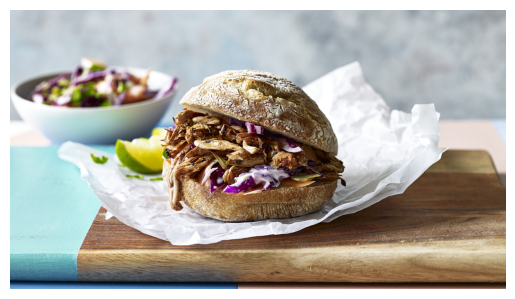

In [3]:
import numpy as np
import matplotlib.pyplot as plt

random_image_path_array=np.asarray(image)
random_image_path_array

plt.imshow(random_image_path_array)
plt.axis(False)

In [4]:
from pathlib import Path

data_path=Path("Dataset/")
train_path=data_path/"train"
train_path

test_path=data_path/"test"
test_path

WindowsPath('Dataset/test')

In [5]:
from torchvision import transforms

data_transform=transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.ToTensor()
])

Text(0.5, 1.0, 'Transformed Image')

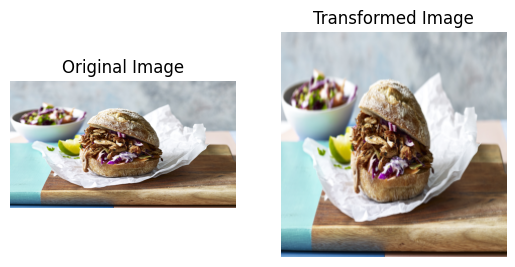

In [6]:
fig,ax=plt.subplots(1,2)

ax[0].imshow(image)
ax[0].axis("off")
ax[0].set_title("Original Image")

transformed_image=data_transform(image).permute(1,2,0)
ax[1].imshow(transformed_image)
ax[1].axis("off")
ax[1].set_title("Transformed Image")

In [7]:
from torchvision import datasets

train_dataset=datasets.ImageFolder(root=train_path,transform=data_transform,target_transform=None)
test_dataset=datasets.ImageFolder(root=test_path,transform=data_transform)

print(f"{train_dataset}\n{test_dataset}")

Dataset ImageFolder
    Number of datapoints: 3566
    Root location: Dataset\train
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )
Dataset ImageFolder
    Number of datapoints: 1111
    Root location: Dataset\test
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )


In [8]:
classes=train_dataset.classes
classes

['burger',
 'butter_naan',
 'chai',
 'chapati',
 'chole_bhature',
 'dal_makhani',
 'dhokla',
 'fried_rice',
 'idli',
 'jalebi',
 'kaathi_rolls',
 'kadai_paneer',
 'kulfi',
 'masala_dosa',
 'momos',
 'pav_bhaji',
 'pizza']

In [9]:
classes_id=train_dataset.class_to_idx
print(classes_id)

{'burger': 0, 'butter_naan': 1, 'chai': 2, 'chapati': 3, 'chole_bhature': 4, 'dal_makhani': 5, 'dhokla': 6, 'fried_rice': 7, 'idli': 8, 'jalebi': 9, 'kaathi_rolls': 10, 'kadai_paneer': 11, 'kulfi': 12, 'masala_dosa': 13, 'momos': 14, 'pav_bhaji': 15, 'pizza': 16}


torch.Size([3, 224, 224])
0
torch.Size([224, 224, 3])


(-0.5, 223.5, 223.5, -0.5)

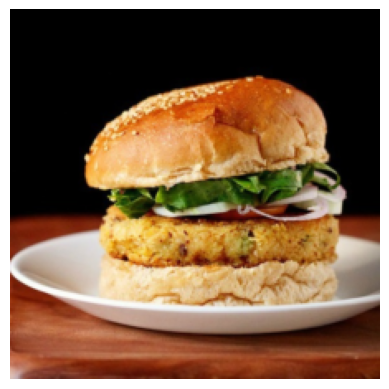

In [10]:
train_image,label=train_dataset[20][0],train_dataset[20][1]
print(train_image.shape)
print(label)

train_image_sample=train_image.permute(1,2,0)
print(train_image_sample.shape)
plt.imshow(train_image_sample)
plt.axis(False)

In [11]:
from torch.utils.data import DataLoader

train_dataloader=DataLoader(dataset=train_dataset,batch_size=32,shuffle=True)
test_dataloader=DataLoader(dataset=test_dataset,batch_size=32,shuffle=False)

print(f"{train_dataloader}\n{test_dataloader}")

In [12]:
img,label=next(iter(train_dataloader))

print(img.shape)
print(label.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


First image shape torch.Size([3, 224, 224])
First image from train data loader
tensor([[[0.0863, 0.0863, 0.0863,  ..., 0.0980, 0.0980, 0.0980],
         [0.0863, 0.0863, 0.0863,  ..., 0.0980, 0.0980, 0.0980],
         [0.0863, 0.0863, 0.0863,  ..., 0.0980, 0.0980, 0.0980],
         ...,
         [0.5490, 0.5451, 0.5294,  ..., 0.5137, 0.4902, 0.4667],
         [0.5529, 0.5373, 0.5176,  ..., 0.5098, 0.4980, 0.4706],
         [0.5569, 0.5373, 0.5098,  ..., 0.5059, 0.5020, 0.4745]],

        [[0.0706, 0.0706, 0.0706,  ..., 0.0824, 0.0824, 0.0824],
         [0.0706, 0.0706, 0.0706,  ..., 0.0824, 0.0824, 0.0824],
         [0.0706, 0.0706, 0.0706,  ..., 0.0824, 0.0824, 0.0824],
         ...,
         [0.3765, 0.3725, 0.3569,  ..., 0.3333, 0.3098, 0.2863],
         [0.3804, 0.3647, 0.3451,  ..., 0.3333, 0.3255, 0.3020],
         [0.3843, 0.3647, 0.3373,  ..., 0.3333, 0.3333, 0.3098]],

        [[0.0745, 0.0745, 0.0745,  ..., 0.0863, 0.0863, 0.0863],
         [0.0745, 0.0745, 0.0745,  ..., 0.08

(-0.5, 223.5, 223.5, -0.5)

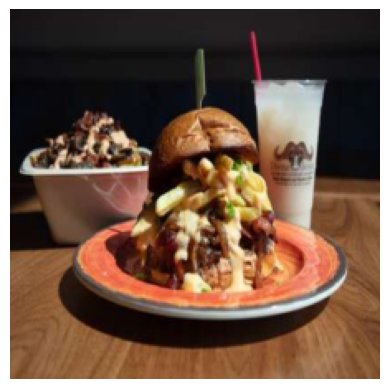

In [13]:
img_single=img[0]
print(f"First image shape {img_single.shape}")
print(f"First image from train data loader\n{img_single}")

img_single_permute=img_single.permute(1,2,0)
plt.imshow(img_single_permute)
plt.axis(False)

In [14]:
import torch
from torch import nn
from torchvision import models 
from torchvision.models import ResNet50_Weights

weights=ResNet50_Weights.IMAGENET1K_V2
model=models.resnet50(weights=weights)

num_features=model.fc.in_features
model.fc=nn.Linear(in_features=num_features,out_features=len(classes))

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [15]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model.parameters(),lr=0.001)

In [ ]:
from tqdm import tqdm

torch.manual_seed(7)

epochs=3

for epoch in range(epochs):
    print(f"\nEpoch : {epoch+1}/{epochs}")
    model.train()
    train_loss=0

    # Total training images count
    total_train_images = 0

    # Wrap dataloader with tqdm for progress bar
    for X, y in tqdm(train_dataloader, desc="Training", leave=False):
        total_train_images += X.size(0)  # Add batch size

        # 1) Forward pass
        output = model(X)

        # 2) Loss function
        loss = loss_fn(output, y)

        # 3) optimizer zero_grad
        optimizer.zero_grad()

        # 4) Loss backward
        loss.backward()

        # 5) optimizer step
        optimizer.step()

        train_loss += loss.item()

    print(f"Total training images this epoch: {total_train_images}")
    print(f"Train loss: {train_loss / len(train_dataloader):.4f}")

    model.eval()
    test_loss, test_acc = 0, 0
    total_test_images = 0

    with torch.inference_mode():
        for X, y in tqdm(test_dataloader, desc="Testing", leave=False):
            total_test_images += X.size(0)

            # 1) Forward pass
            test_output = model(X)

            # 2) Loss function
            loss = loss_fn(test_output, y)
            test_loss += loss.item()

            test_pred_labels = torch.argmax(test_output, dim=1)
            test_acc += (test_pred_labels == y).sum().item() / len(test_pred_labels)

    print(f"Total testing images this epoch: {total_test_images}")
    print(f"Test loss: {test_loss / len(test_dataloader):.4f}")
    print(f"Test accuracy: {test_acc / len(test_dataloader):.4f}")



Epoch : 1/3


Total training images this epoch: 3566
Train loss: 2.7988


Total testing images this epoch: 1111
Test loss: 2.7633
Test accuracy: 0.1673

Epoch : 2/3


Total training images this epoch: 3566
Train loss: 2.7271


Total testing images this epoch: 1111
Test loss: 2.6949
Test accuracy: 0.2864

Epoch : 3/3


Training:  41%|████      | 46/112 [14:33<24:12, 22.00s/it]

In [1]:
import torchvision
import torch

custom_image_path='./Dataset/chai.jpg'
custom_image=torchvision.io.read_image(str(custom_image_path)).type(torch.float32)

custom_image=custom_image/255

print(custom_image.shape)
print(custom_image)

torch.Size([3, 1800, 1800])
tensor([[[0.9216, 0.9216, 0.9216,  ..., 0.7412, 0.7412, 0.7412],
         [0.9216, 0.9216, 0.9216,  ..., 0.7412, 0.7412, 0.7412],
         [0.9216, 0.9216, 0.9216,  ..., 0.7412, 0.7412, 0.7412],
         ...,
         [0.8039, 0.8039, 0.8078,  ..., 0.7961, 0.7961, 0.7961],
         [0.8039, 0.8039, 0.8078,  ..., 0.7961, 0.7961, 0.7961],
         [0.8039, 0.8039, 0.8078,  ..., 0.7961, 0.7961, 0.7961]],

        [[0.8902, 0.8902, 0.8902,  ..., 0.5843, 0.5843, 0.5843],
         [0.8902, 0.8902, 0.8902,  ..., 0.5843, 0.5843, 0.5843],
         [0.8902, 0.8902, 0.8902,  ..., 0.5843, 0.5843, 0.5843],
         ...,
         [0.8039, 0.8039, 0.8078,  ..., 0.6157, 0.6157, 0.6157],
         [0.8039, 0.8039, 0.8078,  ..., 0.6157, 0.6157, 0.6157],
         [0.8039, 0.8039, 0.8078,  ..., 0.6157, 0.6157, 0.6157]],

        [[0.8471, 0.8471, 0.8471,  ..., 0.5843, 0.5843, 0.5843],
         [0.8471, 0.8471, 0.8471,  ..., 0.5843, 0.5843, 0.5843],
         [0.8471, 0.8471, 0.84

(-0.5, 1799.5, 1799.5, -0.5)

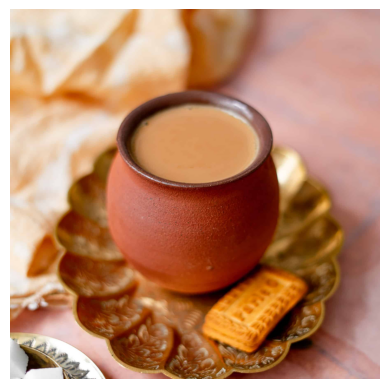

In [2]:
import matplotlib.pyplot as plt

plt.imshow(custom_image.permute(1,2,0))
plt.axis(False)

In [3]:
from torchvision import transforms

custom_image_transform=transforms.Compose([
    transforms.Resize(size=(224,224))
])

custom_image_transformed=custom_image_transform(custom_image)
print(f"Transformed shape is {custom_image_transformed.shape}")

Transformed shape is torch.Size([3, 224, 224])


In [10]:
import torch
models=torch.load('./Trained_model.pth')

models.eval()

with torch.inference_mode():
    custom_image_transformed_with_batch_size = custom_image_transformed.unsqueeze(dim=0)
    print(f"Unsqueezed custom image shape: {custom_image_transformed_with_batch_size.shape}")

    custom_image_pred=models(custom_image_transformed.unsqueeze(dim=0))

Unsqueezed custom image shape: torch.Size([1, 3, 224, 224])


In [11]:
print(f"Prediction logits : {custom_image_pred}")

custom_image_pred_label=torch.argmax(custom_image_pred)
print(f"Prediction label : {custom_image_pred_label}")

Prediction logits : tensor([[-0.5712, -1.3299,  4.7468, -0.3856, -0.5113,  0.8301, -0.5261, -1.3742,
          0.6643, -0.9611, -0.7012, -1.5202,  0.3482,  0.8892]])
Prediction label : 2


In [13]:
classes=['burger',
 'butter_naan',
 'chai',
 'chapati',
 'chole_bhature',
 'dal_makhani',
 'dhokla',
 'fried_rice',
 'idli',
 'jalebi',
 'kaathi_rolls',
 'kadai_paneer',
 'kulfi',
 'masala_dosa']

custom_image_pred_class=classes[custom_image_pred_label]
print(f"Predicted label is : {custom_image_pred_class}")

Predicted label is : chai


In [ ]:
import torch

torch.save(model,'Trained_model.pth')

In [7]:
import torch
models=torch.load('./Trained_model.pth')

In [10]:
models.eval()

with torch.inference_mode():
    custom_image_transformed_with_batch_size = custom_image_transformed.unsqueeze(dim=0)
    print(f"Unsqueezed custom image shape: {custom_image_transformed_with_batch_size.shape}")

    custom_image_pred=models(custom_image_transformed.unsqueeze(dim=0))

Unsqueezed custom image shape: torch.Size([1, 3, 224, 224])


In [11]:
print(f"Prediction logits : {custom_image_pred}")

custom_image_pred_label=torch.argmax(custom_image_pred)
print(f"Prediction label : {custom_image_pred_label}")

Prediction logits : tensor([[-0.5712, -1.3299,  4.7468, -0.3856, -0.5113,  0.8301, -0.5261, -1.3742,
          0.6643, -0.9611, -0.7012, -1.5202,  0.3482,  0.8892]])
Prediction label : 2


In [12]:
classes=['burger',
 'butter_naan',
 'chai',
 'chapati',
 'chole_bhature',
 'dal_makhani',
 'dhokla',
 'fried_rice',
 'idli',
 'jalebi',
 'kaathi_rolls',
 'kadai_paneer',
 'kulfi',
 'masala_dosa']

custom_image_pred_class=classes[custom_image_pred_label]
print(f"Predicted label is : {custom_image_pred_class}")

Predicted label is : chai
